# Stock Price Prediction using LSTM
## Training Model on RELIANCE.NS Stock

In [1]:
## Import Libraries
import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

## Step 1: Download NIFTY 50 Stock Data (5 Years)

In [2]:
## NIFTY 50 Stock List
nifty50_stocks = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS",
    "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "KOTAKBANK.NS",
    "LT.NS", "AXISBANK.NS", "BAJFINANCE.NS", "ASIANPAINT.NS", "MARUTI.NS",
    "HCLTECH.NS", "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS", "NESTLEIND.NS",
    "WIPRO.NS", "ONGC.NS", "NTPC.NS", "POWERGRID.NS", "ADANIENT.NS",
    "ADANIPORTS.NS", "BAJAJFINSV.NS", "BAJAJ-AUTO.NS", "BRITANNIA.NS",
    "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "INDUSINDBK.NS", "JSWSTEEL.NS",
    "M&M.NS", "SBILIFE.NS", "SHREECEM.NS", "TECHM.NS", "TATASTEEL.NS",
    "TATACONSUM.NS", "TATAMOTORS.NS", "UPL.NS", "DIVISLAB.NS", "APOLLOHOSP.NS",
    "BPCL.NS", "HDFCLIFE.NS"
]

print(f"Total stocks: {len(nifty50_stocks)}")

Total stocks: 50


In [3]:
## Download 5 years data for all NIFTY 50 stocks
import yfinance as yf
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

for stock in nifty50_stocks:
    try:
        print(f"Downloading {stock}...")
        data = yf.download(stock, period="5y")
        
        if not data.empty:
            filename = f"data/{stock.replace('.NS', '')}.csv"
            data.to_csv(filename)
            print(f"✓ Saved {filename} - Shape: {data.shape}")
        else:
            print(f"✗ No data for {stock}")
    except Exception as e:
        print(f"✗ Error downloading {stock}: {e}")

print("\n✓ Data download completed!")

[*********************100%***********************]  1 of 1 completed


✓ Saved data/RELIANCE.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


✓ Saved data/TCS.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


...

✓ Saved data/APOLLOHOSP.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


✓ Saved data/BPCL.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed

✓ Saved data/HDFCLIFE.csv - Shape: (1236, 5)

✓ Data download completed!


## Step 2: Load and Explore RELIANCE Stock Data (Training Stock)

In [4]:
## Load RELIANCE data for training
df = pd.read_csv('data/RELIANCE.csv', index_col=0, parse_dates=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1238, 5)

First 5 rows:
                        Close                High                Low  \
Price                                                                  
Ticker            RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
Date                      NaN                 NaN                NaN   
2021-03-10     989.3642578125  1004.3955499162571  984.0591241137868   
2021-03-12  969.2547607421875  1000.4508052727284  963.0427293609322   
2021-03-15  956.2411499023438    974.378367439583  943.3636702802955   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816784252693     16864952  
2021-03-15   970.3655452396614     16698099  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1238 entries, Ticker to 2026-03-10
Data columns (total 5 columns):
 #   C

In [5]:
print(df.head())
print(df.dtypes)

                        Close                High                Low  \
Price                                                                  
Ticker            RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
Date                      NaN                 NaN                NaN   
2021-03-10     989.3642578125  1004.3955499162571  984.0591241137868   
2021-03-12  969.2547607421875  1000.4508052727284  963.0427293609322   
2021-03-15  956.2411499023438    974.378367439583  943.3636702802955   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816784252693     16864952  
2021-03-15   970.3655452396614     16698099  
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object


In [6]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

In [7]:
df = df.dropna(subset=['Close'])

In [8]:
df.index

Index(['2021-03-10', '2021-03-12', '2021-03-15', '2021-03-16', '2021-03-17',
       '2021-03-18', '2021-03-19', '2021-03-22', '2021-03-23', '2021-03-24',
       ...
       '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
       '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10'],
      dtype='object', name='Price', length=1236)

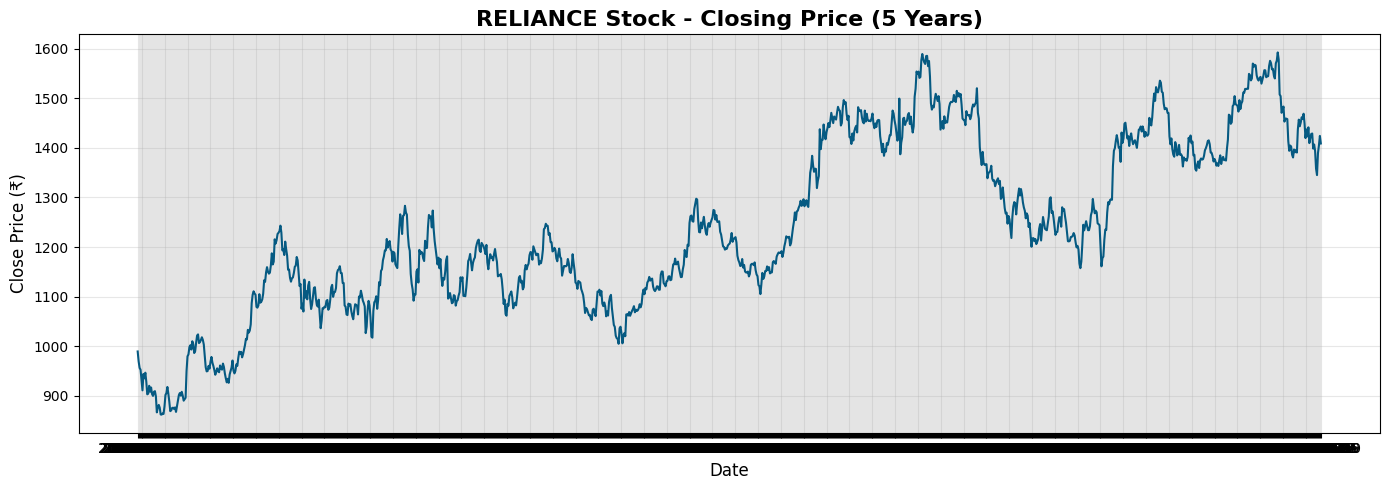

In [9]:
## Visualize Closing Price
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='#065A82', linewidth=1.5)
plt.title('RELIANCE Stock - Closing Price (5 Years)', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (₹)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Feature Selection - Using Close Price Only

In [10]:
## Select Close price for prediction
data = df[['Close']].values

print(f"Data shape: {data.shape}")
print(f"Total days: {len(data)}")

Data shape: (1236, 1)
Total days: 1236


## Step 4: Data Scaling (MinMaxScaler)

In [11]:
## Scaling data to range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original data range: {data.min():.2f} to {data.max():.2f}")
print(f"Scaled data range: {scaled_data.min():.2f} to {scaled_data.max():.2f}")

## Save scaler for future predictions
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    
print("\n✓ Scaler saved as 'scaler.pkl'")

Original data range: 862.04 to 1592.30
Scaled data range: 0.00 to 1.00

✓ Scaler saved as 'scaler.pkl'


## Step 5: Create Sequences for LSTM (60 days lookback)

In [12]:
## Create sequences: Use past 60 days to predict next day
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])  # Past 60 days
    y.append(scaled_data[i, 0])  # Next day price

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1176, 60)
y shape: (1176,)


## Step 6: Train-Test Split (80-20)

In [13]:
## Split: 80% training, 20% testing
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 940
Testing samples: 236


In [14]:
## Reshape for LSTM: (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (940, 60, 1)
X_test shape: (236, 60, 1)


## Step 7: Build LSTM Model

In [15]:
## LSTM Model Architecture
model = Sequential()

# First LSTM layer with Dropout
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers
model.add(Dense(units=25, activation='relu'))
model.add(Dense(units=1))  ## Output layer

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("✓ Model Built Successfully!")
model.summary()

✓ Model Built Successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train Model with Callbacks

In [16]:
## Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'stock_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Train model
print("\n🚀 Starting Training...\n")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n✓ Training Complete!")


🚀 Starting Training...

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1455 - mae: 0.3040
Epoch 1: val_loss improved from None to 0.00473, saving model to stock_lstm_model.h5



Epoch 1: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - loss: 0.0681 - mae: 0.1857 - val_loss: 0.0047 - val_mae: 0.0564
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0090 - mae: 0.0761
Epoch 2: val_loss improved from 0.00473 to 0.00427, saving model to stock_lstm_model.h5



Epoch 2: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0076 - mae: 0.0685 - val_loss: 0.0043 - val_mae: 0.0523
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0547
Epoch 3: val_loss did not improve from 0.00427
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0050 - mae: 0.0551 - val_loss: 0.0061 - val_mae: 0.0644
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0057 - mae: 0.0571
Epoch 4: val_loss did not improve from 0.00427
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0052 - mae: 0.0561 - val_loss: 0.0051 - val_mae: 0.0575
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0048 - mae: 0.0543
Epoch 5: val_loss improved from 0.00427 to 0.00398, saving model to stock_lstm_model.h5



Epoch 5: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0046 - mae: 0.0535 - val_loss: 0.0040 - val_mae: 0.0494
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0038 - mae: 0.0484
Epoch 6: val_loss did not improve from 0.00398
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0041 - mae: 0.0497 - val_loss: 0.0045 - val_mae: 0.0526
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0043 - mae: 0.0502
Epoch 7: val_loss did not improve from 0.00398
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - loss: 0.0041 - mae: 0.0498 - val_loss: 0.0042 - val_mae: 0.0516
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0043 - mae: 0.0523
Epoch 8: val_loss improved from 0.00398 to 0.00313, saving model to stock_lstm_model.h5



Epoch 8: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0043 - mae: 0.0520 - val_loss: 0.0031 - val_mae: 0.0431
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0037 - mae: 0.0474
Epoch 9: val_loss did not improve from 0.00313
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0040 - mae: 0.0490 - val_loss: 0.0054 - val_mae: 0.0611
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0034 - mae: 0.0457
Epoch 10: val_loss improved from 0.00313 to 0.00301, saving model to stock_lstm_model.h5


...


Epoch 42: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.0018 - mae: 0.0319 - val_loss: 0.0012 - val_mae: 0.0265
Epoch 43/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0016 - mae: 0.0313
Epoch 43: val_loss improved from 0.00125 to 0.00120, saving model to stock_lstm_model.h5



Epoch 43: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 0.0017 - mae: 0.0319 - val_loss: 0.0012 - val_mae: 0.0260
Epoch 44/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0017 - mae: 0.0325
Epoch 44: val_loss did not improve from 0.00120
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.0017 - mae: 0.0319 - val_loss: 0.0013 - val_mae: 0.0272
Epoch 45/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0018 - mae: 0.0326
Epoch 45: val_loss improved from 0.00120 to 0.00120, saving model to stock_lstm_model.h5



Epoch 45: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - loss: 0.0017 - mae: 0.0319 - val_loss: 0.0012 - val_mae: 0.0262
Epoch 46/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - loss: 0.0017 - mae: 0.0312
Epoch 46: val_loss improved from 0.00120 to 0.00109, saving model to stock_lstm_model.h5



Epoch 46: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 546ms/step - loss: 0.0018 - mae: 0.0322 - val_loss: 0.0011 - val_mae: 0.0248
Epoch 47/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0019 - mae: 0.0337
Epoch 47: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - loss: 0.0018 - mae: 0.0326 - val_loss: 0.0015 - val_mae: 0.0304
Epoch 48/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - loss: 0.0020 - mae: 0.0341
Epoch 48: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 540ms/step - loss: 0.0019 - mae: 0.0333 - val_loss: 0.0021 - val_mae: 0.0387
Epoch 49/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - loss: 0.0019 - mae: 0.0329
Epoch 49: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 573ms/step - loss: 0.0020 - mae: 0.0337 - val_loss: 0.0013 - val_mae: 0.0278
Epoch 50/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0020 - mae: 0.0345
Epoch 50: val_loss improved from 0.00109 


Epoch 50: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.0017 - mae: 0.0317 - val_loss: 0.0011 - val_mae: 0.0243
Restoring model weights from the end of the best epoch: 50.

✓ Training Complete!


## Step 9: Visualize Training History

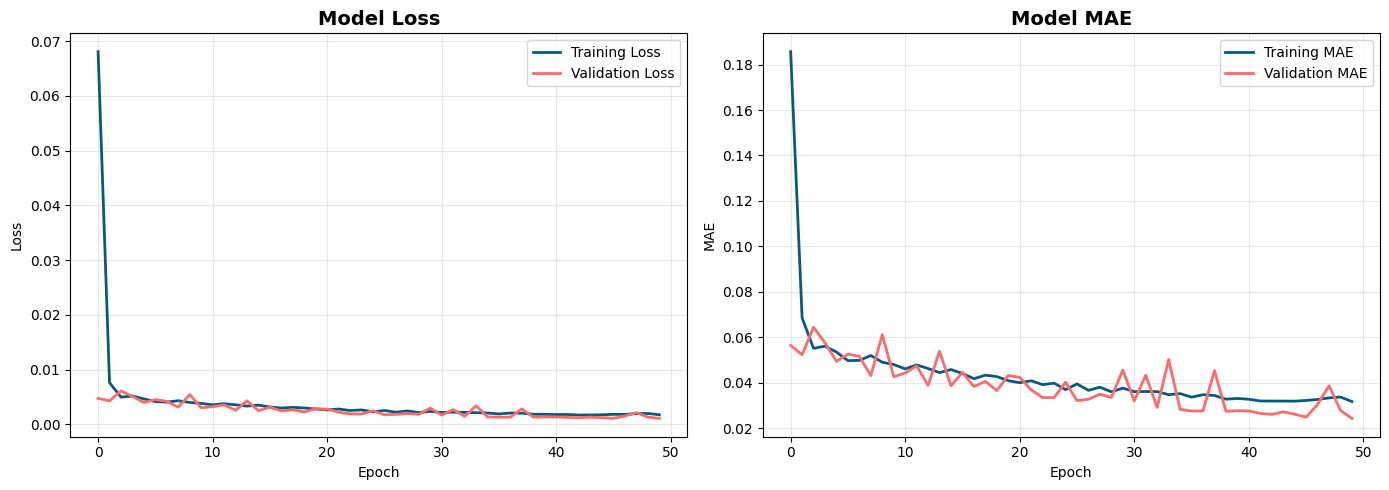

In [17]:
## Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='#065A82', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#FF6B6B', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', color='#065A82', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#FF6B6B', linewidth=2)
axes[1].set_title('Model MAE', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Save Model

In [18]:
## Save final model
model.save("stock_lstm_model.keras")
print("✓ Model saved as 'stock_lstm_model.h5'")

print("\n" + "="*60)
print("✓ TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)
print("\nFiles Created:")
print("  1. stock_lstm_model.h5 - Trained LSTM model")
print("  2. scaler.pkl - MinMaxScaler for preprocessing")
print("  3. data/ - Folder with all NIFTY 50 stock CSVs")
print("\nNext Step: Run 'prediction.ipynb' for testing and evaluation")
print("="*60)

✓ Model saved as 'stock_lstm_model.h5'

✓ TRAINING COMPLETED SUCCESSFULLY!

Files Created:
  1. stock_lstm_model.h5 - Trained LSTM model
  2. scaler.pkl - MinMaxScaler for preprocessing
  3. data/ - Folder with all NIFTY 50 stock CSVs

Next Step: Run 'prediction.ipynb' for testing and evaluation
